In [1]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
from tensorflow.keras.regularizers import l2

2026-02-01 12:56:59.820079: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X, y = make_moons(n_samples=100, noise=0.2, random_state=44, shuffle=True)

In [3]:
X.shape, y.shape

((100, 2), (100,))

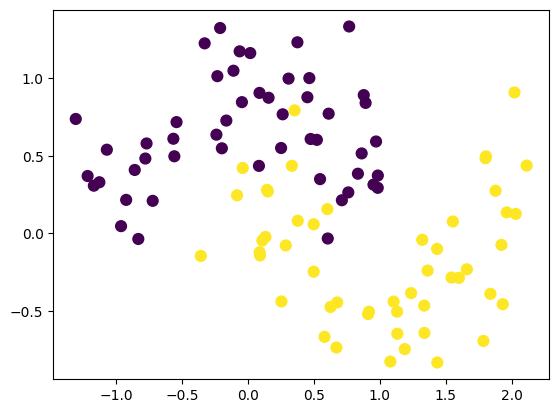

In [4]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, s=60)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

In [6]:
tf.keras.backend.clear_session()
model_without_reg = Sequential()

In [7]:
model_without_reg.add(Input(shape=(2,)))
model_without_reg.add(Dense(128, activation='relu'))
model_without_reg.add(Dense(128, activation='relu'))
model_without_reg.add(Dense(1, activation='sigmoid'))

In [8]:
model_without_reg.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [9]:
history = model_without_reg.fit(X_train, y_train, epochs=600, validation_split=0.2)

Epoch 1/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 0.5781 - loss: 0.6886 - val_accuracy: 0.6250 - val_loss: 0.6634
Epoch 2/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8281 - loss: 0.6502 - val_accuracy: 0.6250 - val_loss: 0.6397
Epoch 3/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8750 - loss: 0.6177 - val_accuracy: 0.6875 - val_loss: 0.6187
Epoch 4/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8750 - loss: 0.5866 - val_accuracy: 0.6875 - val_loss: 0.5995
Epoch 5/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8750 - loss: 0.5594 - val_accuracy: 0.6875 - val_loss: 0.5817
Epoch 6/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8906 - loss: 0.5309 - val_accuracy: 0.6875 - val_loss: 0.5652
Epoch 7/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8906 - loss: 0.5058 - val_accuracy: 0.6875 - val_loss: 0.5494
Epoch 8/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8906 - loss: 0.4793 - val_accuracy: 0.6875 - val_lo

In [10]:
y_pred = np.where(model_without_reg.predict(X_test)>=0.5, 1, 0)
y_pred[:5], y_test[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


(array([[0],
        [0],
        [1],
        [1],
        [0]]),
 array([0, 0, 1, 1, 1]))

In [11]:
accuracy_score(y_test, y_pred)* 100

90.0

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


<Axes: >

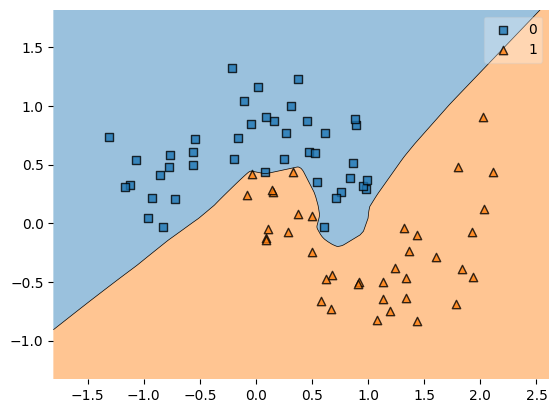

In [12]:
plot_decision_regions(X_train, y_train, clf=model_without_reg, zoom_factor=2)

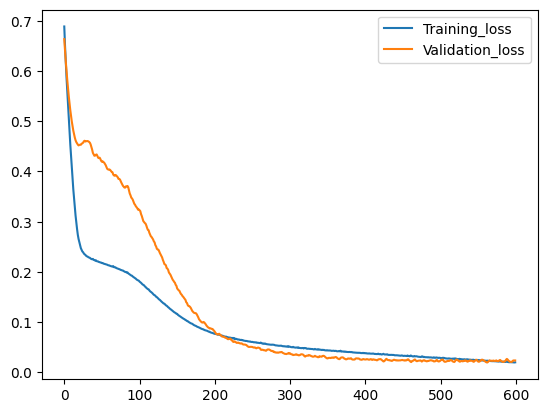

In [13]:
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['val_loss'], label='Validation_loss')
plt.legend()
plt.show()

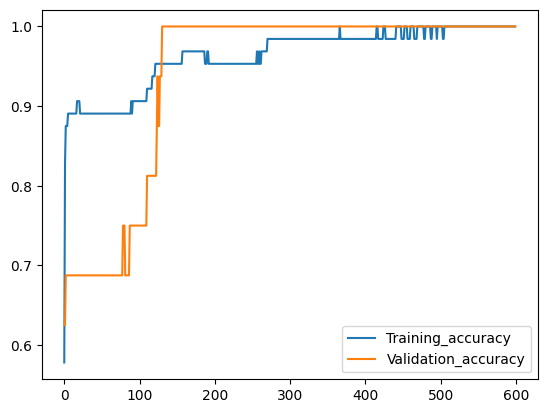

In [14]:
plt.plot(history.history['accuracy'], label='Training_accuracy')
plt.plot(history.history['val_accuracy'], label='Validation_accuracy')
plt.legend()
plt.show()

## now with regularization:

In [27]:
tf.keras.backend.clear_session()
model_with_reg = Sequential()

In [28]:
model_with_reg.add(Input(shape=(2,)))
model_with_reg.add(Dense(128, activation='relu', kernel_regularizer = l2(0.01)))
model_with_reg.add(Dense(128, activation='relu', kernel_regularizer = l2(0.01)))
model_with_reg.add(Dense(1, activation='sigmoid'))

In [29]:
model_with_reg.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [30]:
history = model_with_reg.fit(X_train, y_train, validation_split=0.2, epochs=600)

Epoch 1/600


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.3438 - loss: 2.0386 - val_accuracy: 0.4375 - val_loss: 1.9908
Epoch 2/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6562 - loss: 1.9624 - val_accuracy: 0.7500 - val_loss: 1.9280
Epoch 3/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8750 - loss: 1.8918 - val_accuracy: 0.8125 - val_loss: 1.8685
Epoch 4/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9219 - loss: 1.8277 - val_accuracy: 0.7500 - val_loss: 1.8126
Epoch 5/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8906 - loss: 1.7650 - val_accuracy: 0.6875 - val_loss: 1.7609
Epoch 6/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9062 - loss: 1.7067 - val_accuracy: 0.6875 - val_loss: 1.7119
Epoch 7/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8906 - loss: 1.6515 - val_accuracy: 0.6875 - val_loss: 1.6651
Epoch 8/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8906 - loss: 1.5960 - val_accuracy: 0.6875 - val_loss: 1.6205
Ep

In [31]:
y_pred = np.where(model_with_reg.predict(X_test)>=0.5, 1, 0)
y_pred[:5], y_test[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


(array([[0],
        [0],
        [1],
        [1],
        [1]]),
 array([0, 0, 1, 1, 1]))

In [32]:
accuracy_score(y_test, y_pred)* 100

95.0

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


<Axes: >

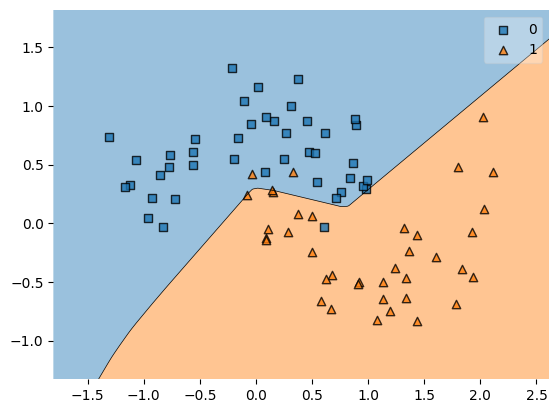

In [33]:
plot_decision_regions(X_train, y_train, clf=model_with_reg, zoom_factor=2)

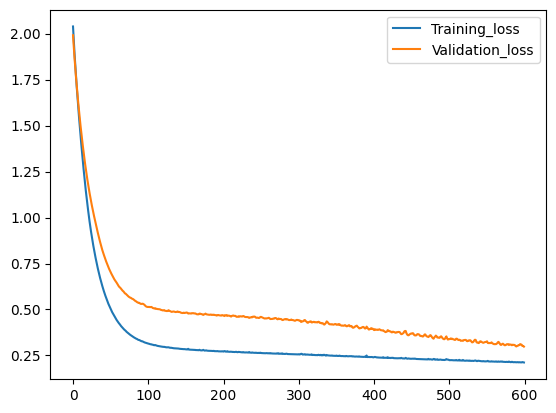

In [34]:
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['val_loss'], label='Validation_loss')
plt.legend()
plt.show()

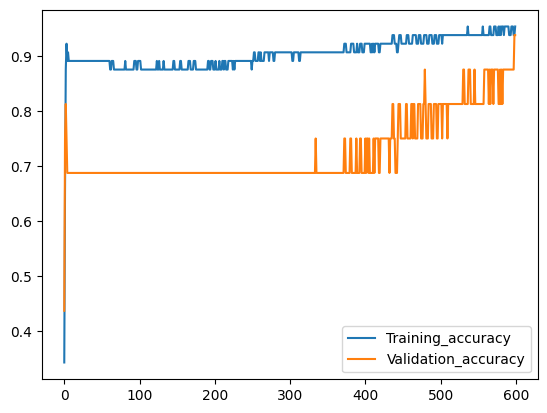

In [35]:
plt.plot(history.history['accuracy'], label='Training_accuracy')
plt.plot(history.history['val_accuracy'], label='Validation_accuracy')
plt.legend()
plt.show()

so above we can see it reduces overfitting and increases accuracy